# 🗄️ Buổi 2: Database Schema & Setup

## 🎯 Mục tiêu buổi này
✅ Chạy lại data từ Buổi 1 để đảm bảo database sẵn sàng

✅ Xem Entity Relationship Diagram (ERD) - mối quan hệ giữa bảng

✅ Phân tích data types & ý nghĩa các cột

✅ Hiểu khóa chính (Primary Key), khóa ngoại (Foreign Key)

✅ Khái niệm Fact table vs Dimension table

✅ Thực hành: 5 bài tập tạo bảng + 5 quiz ôn tập

---

## 📋 BƯỚC 1: Verify database từ Buổi 1

### 1.1 Kết nối PostgreSQL
1. Mở **pgAdmin 4** hoặc **DBeaver**
2. Kết nối database `hr_analytics`
3. Mở **Query Tool** (pgAdmin) hoặc **SQL Editor** (DBeaver)

### 1.2 Chạy verify query
```sql
-- Kiểm tra tất cả bảng đã tạo
SELECT table_name 
FROM information_schema.tables 
WHERE table_schema = 'public' 
ORDER BY table_name;
```
**Kỳ vọng kết quả:**
- departments
- employees
- engagement_surveys
- job_titles
- leavers
- performance_reviews
- salaries

### 1.3 Đếm số records mỗi bảng
```sql
SELECT 
  (SELECT COUNT(*) FROM departments) AS departments,
  (SELECT COUNT(*) FROM job_titles) AS job_titles,
  (SELECT COUNT(*) FROM employees) AS employees,
  (SELECT COUNT(*) FROM salaries) AS salaries,
  (SELECT COUNT(*) FROM performance_reviews) AS performance_reviews,
  (SELECT COUNT(*) FROM engagement_surveys) AS engagement_surveys,
  (SELECT COUNT(*) FROM leavers) AS leavers;
```
**Kỳ vọng:**

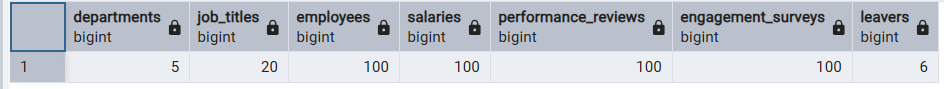

---


## 🔍 BƯỚC 2: Xem Entity Relationship Diagram (ERD)

### 2.1 Trong pgAdmin (Windows/Mac)
1. Tìm database `hr_analytics` ở panel trái -> `Schemas` -> `public`
2. Chuột phải → **ERD For Schema**
3. Một cửa sổ mới hiện lên, vẽ sơ đồ quan hệ các bảng

### 2.2 Trong DBeaver (Windows/Mac)
1. Chuột phải database `hr_analytics`
2. **ER Diagram** → **New Diagram**
3. Chuột phải trên Diagram → **Add Tables** → chọn tất cả 7 bảng

### 2.3 ERD Diagram 

**Nhận xét:** Mọi bảng khác đều **JOIN** về `employees` (trung tâm)

![Untitled.png](C:/Users/ADMIN/Desktop/Untitled.png)


## 📊 BƯỚC 3: Phân tích DATA TYPES & Cột

### 3.1 Xem schema chi tiết
```sql
-- Liệt kê tất cả cột & data type
SELECT 
  table_name,
  column_name,
  data_type,
  is_nullable
FROM information_schema.columns
WHERE table_schema = 'public'
ORDER BY table_name, ordinal_position;
```

### 3.2 Bảng `departments`
| Cột | Data Type | Nullable | Ý nghĩa |
|---|---|---|---|
| dept_id | SERIAL | ❌ | ID phòng ban (khóa chính) |
| dept_name | TEXT | ❌ | Tên phòng (Engineering, Product...) |
| location | TEXT | ❌ | Địa điểm (Hanoi, HCMC...) |
| head_id | INT | ✅ | Quản lý phòng (null = chưa gán) |

### 3.3 Bảng `employees`
| Cột | Data Type | Nullable | Ý nghĩa |
|---|---|---|---|
| emp_id | SERIAL | ❌ | ID nhân viên (PK) |
| first_name | TEXT | ❌ | Tên |
| last_name | TEXT | ❌ | Họ |
| gender | CHAR(1) | ❌ | M/F/O |
| date_of_birth | DATE | ❌ | Ngày sinh (tính tuổi) |
| hired_date | DATE | ❌ | Ngày được tuyển (tính tenure) |
| dept_id | INT | ✅ | FK → departments |
| title_id | INT | ✅ | FK → job_titles |
| manager_id | INT | ✅ | FK → employees (self-join) |
| employment_status | TEXT | ❌ | active/on_leave/terminated |
| city | TEXT | ❌ | Hanoi/HCMC/Da Nang |
| remote_status | TEXT | ❌ | Remote/Hybrid/Onsite |
| education_level | TEXT | ✅ | Bachelor/Master/PhD |

### 3.4 Bảng `salaries`
| Cột | Data Type | Nullable | Ý nghĩa |
|---|---|---|---|
| salary_id | SERIAL | ❌ | ID record (PK) |
| emp_id | INT | ✅ | FK → employees |
| base_salary | NUMERIC(12,2) | ❌ | Lương cơ bản (VND) |
| bonus | NUMERIC(12,2) | ✅ | Thưởng hàng năm |
| effective_date | DATE | ❌ | Ngày hiệu lực |

### 3.5 Bảng `performance_reviews`
| Cột | Data Type | Nullable | Ý nghĩa |
|---|---|---|---|
| review_id | SERIAL | ❌ | ID review (PK) |
| emp_id | INT | ✅ | FK → employees |
| review_date | DATE | ❌ | Ngày đánh giá |
| performance_score | INT | ❌ | 1-10 (1 tệ, 10 xuất sắc) |
| rating | TEXT | ❌ | Exceeds/Meets/Below expectation |
| promo_recommendation | BOOLEAN | ✅ | Có nên thăng chức? |

### 3.6 Bảng `engagement_surveys`
| Cột | Data Type | Nullable | Ý nghĩa |
|---|---|---|---|
| response_id | SERIAL | ❌ | ID response (PK) |
| emp_id | INT | ✅ | FK → employees |
| survey_date | DATE | ❌ | Ngày khảo sát |
| engagement_score | INT | ❌ | 1-10 (gắn bó công ty) |
| wellbeing_score | INT | ❌ | 1-10 (sức khỏe tinh thần) |
| nps_score | INT | ❌ | -100 đến 100 (NPS: sẽ giới thiệu?) |

### 3.7 Bảng `leavers`
| Cột | Data Type | Nullable | Ý nghĩa |
|---|---|---|---|
| leaver_id | SERIAL | ❌ | ID (PK) |
| emp_id | INT | ✅ | FK → employees (terminated) |
| leaving_date | DATE | ❌ | Ngày nghỉ việc |
| reason | TEXT | ✅ | Lý do nghỉ |
| exit_type | TEXT | ❌ | Voluntary/Involuntary/Retirement |
| rehired | BOOLEAN | ❌ | Có được tuyển lại? |

## 🔐 BƯỚC 4: Khóa chính (Primary Key) & Khóa ngoại (Foreign Key)

### 4.1 Primary Key (PK) - Khóa chính
**Định nghĩa:** Cột duy nhất xác định 1 record, không NULL, không trùng lặp.

| Bảng | PK |
|---|---|
| departments | dept_id |
| job_titles | title_id |
| employees | emp_id |
| salaries | salary_id |
| performance_reviews | review_id |
| engagement_surveys | response_id |
| leavers | leaver_id |

### 4.2 Foreign Key (FK) - Khóa ngoại
**Định nghĩa:** Cột tham chiếu đến PK của bảng khác, đảm bảo tính nhất quán (referential integrity).

| Bảng | FK | Tham chiếu |
|---|---|---|
| employees | dept_id | departments.dept_id |
| employees | title_id | job_titles.title_id |
| employees | manager_id | employees.emp_id (self-join) |
| salaries | emp_id | employees.emp_id |
| performance_reviews | emp_id | employees.emp_id |
| engagement_surveys | emp_id | employees.emp_id |
| leavers | emp_id | employees.emp_id |

### 4.3 Ví dụ FK constraint
```sql
-- Nếu thêm employees với dept_id không tồn tại → LỖI!
INSERT INTO employees (..., dept_id, ...) 
VALUES (..., 999, ...);  -- dept_id 999 không tồn tại
-- ERROR: insert or update on table "employees" violates foreign key constraint
```

### 4.4 Query để xem FK
```sql
SELECT 
  constraint_name,
  table_name,
  column_name,
  referenced_table_name,
  referenced_column_name
FROM information_schema.referential_constraints
WHERE constraint_schema = 'public';
```

## 📐 BƯỚC 5: Khái niệm Fact Table vs Dimension Table

### 5.1 Dimension Table (bảng chiều)
**Mục đích:** Lưu trữ thông tin tĩnh, mô tả (lookup data)

**Đặc điểm:**
- Dữ liệu thay đổi chậm (slowly changing)
- Ít rows (hàng chục, hàng trăm)
- Giúp "mô tả" dữ liệu chính

**Ví dụ trong project:**
- `departments` - 5 rows (mô tả phòng ban)
- `job_titles` - 20 rows (mô tả vị trí)
- `employees` - 100 rows (mô tả nhân sự)

### 5.2 Fact Table (bảng sự kiện)
**Mục đích:** Lưu trữ các "facts" định lượng, sự kiện xảy ra

**Đặc điểm:**
- Dữ liệu thay đổi thường xuyên
- Nhiều rows (hàng nghìn, triệu)
- Chứa FK tham chiếu đến Dimension tables
- Chứa các số liệu định lượng (measures)

**Ví dụ trong project:**
- `salaries` - 100+ rows (lương hàng tháng/năm)
- `performance_reviews` - 100+ rows (đánh giá)
- `engagement_surveys` - 100+ rows (khảo sát)
- `leavers` - 6 rows (sự kiện nghỉ việc)

### 5.3 Schema Star (Star Schema)
```
        ┌────────────────┐
        │   job_titles   │
        └────────┬───────┘
                 │
    ┌────────────┼────────────┐
    │            │            │
┌───▼───┐   ┌───▼────────┐   │
│  dept │   │ employees  │   │
└───┬───┘   └───┬────────┘   │
    │           │            │
    │    ┌──────┴──────┐     │
    │    │             │     │
    │┌───▼─────┬───────▼──┬──▼─────────┬───────────────┐
    ││salaries │performance│engagement  │   leavers     │
    │└─────────┴───────────┴────────────┴───────────────┘
    │
    └─ Dimension Table
    
    └─ Fact Table (dưới cùng)
```

## 🎯 BƯỚC 6: Mối quan hệ giữa các bảng (Relationships)

### 6.1 One-to-Many (1:N)
```sql
-- 1 department có nhiều employees
SELECT 
  d.dept_name,
  COUNT(e.emp_id) as emp_count
FROM departments d
LEFT JOIN employees e ON d.dept_id = e.dept_id
GROUP BY d.dept_name;
```

### 6.2 Self-Join (tham chiếu chính nó)
```sql
-- Mỗi employee có manager_id tham chiếu đến emp_id của employee khác
SELECT 
  e.first_name || ' ' || e.last_name AS employee,
  m.first_name || ' ' || m.last_name AS manager
FROM employees e
LEFT JOIN employees m ON e.manager_id = m.emp_id
LIMIT 10;
```

### 6.3 Many-to-One (N:1) through Foreign Keys
```sql
-- 100 salary records tham chiếu đến 100 employees
SELECT 
  e.emp_id,
  e.first_name,
  s.base_salary,
  s.bonus
FROM employees e
JOIN salaries s ON e.emp_id = s.emp_id
LIMIT 5;
```

## 💪 BƯỚC 7: Thực hành - 5 bài tập tạo bảng (Practice Exercises)

### Bài 1: Tạo bảng `company_projects`
**Yêu cầu:**
- project_id (SERIAL, PK)
- project_name (TEXT, NOT NULL)
- dept_id (INT, FK → departments)
- budget (NUMERIC(12,2))
- start_date (DATE)
- end_date (DATE)
- status (TEXT, CHECK IN 'Active','Completed','On Hold')

```sql
-- Viết câu lệnh CREATE TABLE ở đây

```

### Bài 2: Tạo bảng `training_courses`
**Yêu cầu:**
- course_id (SERIAL, PK)
- course_name (TEXT, NOT NULL)
- provider (TEXT)
- duration_days (INT)
- cost (NUMERIC(10,2))
- level (TEXT)

```sql
-- Viết câu lệnh CREATE TABLE ở đây

```

### Bài 3: Tạo bảng `employee_training` (tạo mối quan hệ N:N)
**Yêu cầu:**
- enrollment_id (SERIAL, PK)
- emp_id (INT, FK → employees)
- course_id (INT, FK → training_courses)
- enrollment_date (DATE)
- completion_date (DATE)
- score (INT, CHECK 0-100)

```sql
-- Viết câu lệnh CREATE TABLE ở đây

```

### Bài 4: Tạo bảng `benefits` (mô tả các phúc lợi)
**Yêu cầu:**
- benefit_id (SERIAL, PK)
- benefit_name (TEXT, NOT NULL)
- description (TEXT)
- cost_monthly (NUMERIC(10,2))
- active (BOOLEAN)

```sql
-- Viết câu lệnh CREATE TABLE ở đây

```

### Bài 5: Tạo bảng `employee_benefits` (n:n join)
**Yêu cầu:**
- enrollment_id (SERIAL, PK)
- emp_id (INT, FK → employees)
- benefit_id (INT, FK → benefits)
- enrolled_date (DATE)
- status (TEXT, CHECK IN 'Active','Inactive')

```sql
-- Viết câu lệnh CREATE TABLE ở đây

```

## 📝 BƯỚC 8: 5 Câu hỏi Quiz (Cơ bản → Nâng cao)

### Quiz 1 (Cơ bản): Data Types
**Câu hỏi:** Data type nào dùng cho "Ngày tháng năm" trong PostgreSQL?
- A) TEXT
- B) DATE ✅
- C) INT
- D) NUMERIC

**Giải thích:** DATE lưu định dạng 'YYYY-MM-DD', TEXT phức tạp hơn, INT không phù hợp cho ngày tháng.

---

### Quiz 2 (Cơ bản): Primary Key
**Câu hỏi:** Khóa chính (PK) có thể NULL được không?
- A) Có, tuỳ tùng hợp
- B) Không, PK luôn NOT NULL ✅
- C) Có, nhưng không nên
- D) Không có quy tắc rõ ràng

**Giải thích:** PK phải duy nhất + NOT NULL theo quy định SQL standard.

---

### Quiz 3 (Trung cấp): Foreign Key
**Câu hỏi:** Nếu `employees.dept_id` là FK → `departments.dept_id`, điều gì xảy ra khi DELETE một row từ `departments`?
- A) Xóa thành công, không ảnh hưởng
- B) Lỗi FK constraint ✅ (mặc định)
- C) Xóa luôn employees của phòng đó
- D) Cảnh báo nhưng vẫn xóa

**Giải thích:** Mặc định RESTRICT (từ chối xóa nếu có FK child). Có thể config CASCADE để xóa child.

---

### Quiz 4 (Trung cấp): Fact vs Dimension
**Câu hỏi:** Bảng nào là Fact Table?
- A) job_titles
- B) departments
- C) performance_reviews ✅
- D) employees

**Giải thích:** Fact tables chứa sự kiện định lượng (điểm performance, ...), Dimension tables chứa lookup data (phòng, vị trí).

---

### Quiz 5 (Nâng cao): Self-Join + Relationship
**Câu hỏi:** `employees.manager_id` tham chiếu `employees.emp_id` là loại mối quan hệ nào?
- A) One-to-Many giữa 2 bảng khác nhau
- B) Self-referencing One-to-Many ✅
- C) Many-to-Many
- D) Không có mối quan hệ

**Giải thích:** 1 nhân viên quản lý nhiều nhân viên khác, tạo cấu trúc cây (hierarchy). Self-join khi FK và PK cùng bảng.

## 📚 BƯỚC 9: Tài liệu tham khảo & Links

### 9.1 PostgreSQL Documentation
- 📖 [PostgreSQL Official Docs - Data Types](https://www.postgresql.org/docs/current/datatype.html)
- 📖 [PostgreSQL - Constraints](https://www.postgresql.org/docs/current/ddl-constraints.html)
- 📖 [PostgreSQL - DDL (CREATE TABLE)](https://www.postgresql.org/docs/current/sql-createtable.html)

### 9.2 Database Design & Concepts
- 📘 [Star Schema & Dimensional Modeling](https://en.wikipedia.org/wiki/Star_schema)
- 📗 [Normalization - Wikipedia](https://en.wikipedia.org/wiki/Database_normalization)
- 📙 [ERD - Entity Relationship Diagram](https://www.lucidchart.com/pages/er-diagrams)
- 📕 [Primary & Foreign Keys - Oracle Docs](https://docs.oracle.com/en/database/oracle/oracle-database/21/sqlrf/constraint.html)

### 9.3 Best Practices
- 🎯 [Database Naming Conventions](https://www.sqlshack.com/en/database-naming-conventions/)
- 🎯 [When to use SERIAL vs UUID](https://www.postgresql.org/docs/current/datatype-uuid.html)
- 🎯 [Data Types Best Practices](https://www.cybertec-postgresql.com/en/postgresql-data-types/)

### 9.4 Tools & Visualization
- 🛠️ [dbdiagram.io](https://dbdiagram.io) - Vẽ ERD online
- 🛠️ [DBeaver - Free SQL Client](https://dbeaver.io)
- 🛠️ [pgAdmin 4](https://www.pgadmin.org/)
- 🛠️ [Datagrip - JetBrains IDE](https://www.jetbrains.com/datagrip/)

### 9.5 Khóa học online
- 🎓 [Udemy - SQL & Database Design](https://www.udemy.com/course/the-complete-sql-bootcamp/)
- 🎓 [Coursera - Databases Specialization](https://www.coursera.org/specializations/databases)
- 🎓 [Khan Academy - SQL Basics](https://www.khanacademy.org/computing/computer-programming/sql)

### 9.6 Bài viết hữu ích (Tiếng Việt)
- 📄 [PostgreSQL Cơ bản - TechBlog](https://techblog.vn/)
- 📄 [Database Design - Viblo](https://viblo.asia/)
- 📄 [SQL Optimization - Medium](https://medium.com/)

## 🎓 Kết luận Buổi 2

✅ **Bạn vừa hoàn thành:**
- Verify database từ Buổi 1
- Xem ERD - hiểu mối quan hệ giữa 7 bảng
- Phân tích 7 data types chính (SERIAL, TEXT, DATE, INT, NUMERIC, BOOLEAN, CHAR)
- Nắm concept khóa chính (PK) & khóa ngoại (FK)
- Phân biệt Fact table vs Dimension table
- Thực hành 5 bài tập CREATE TABLE
- Ôn tập 5 quiz từ cơ bản → nâng cao

📅 **Buổi 3**: Employee Overview Analysis - bắt đầu viết query
- SELECT, WHERE, ORDER BY cơ bản
- JOIN các bảng
- Aggregate functions (COUNT, SUM, AVG)

---

💡 **Ghi chú quan trọng:**
- PostgreSQL là Open Source, miễn phí, mạnh mẽ.
- ERD giúp bạn "nhìn thấy" dữ liệu trước khi viết query.
- PK + FK đảm bảo tính nhất quán dữ liệu (Data Integrity).
- Fact/Dimension schema giúp tối ưu truy vấn phân tích.

🚀 **Hãy thực hành 5 bài tập trên để nắm vững hơn!**